# Exercise 1: Linear Algebra (20 points)

One of the challenges in machine learning is moving from the formal linear algebra formulation to a practical implementation with discrete vectors.

Let us look again at the NAND gate implementation with a single perceptron node.
The node has two inputs $x_1$ and $x_2$ and a single output.

The perceptron node implements a transformation between input $\vec{x}$ and output $y$ described by
$$y = f({\bf x}; {\bf w}, b) = {\bf w}^T {\bf x} + b.$$



## Describe the form of the input ${\bf x}$.

Is it a column vector
$\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}$
 or a row vector
$\begin{bmatrix}
x_1
x_2
\end{bmatrix}$
 ? If it were to be implemented as a PyTorch tensor, what should its dimensions be?
 
## Answer:
 It will be a row vector $\begin{bmatrix}
x_1
x_2
\end{bmatrix}$
. Looking at matrix multiplication, for a product to be 1x1 (a single output), the matrices being multiplied must be 1xn and nx1 respectively. As a PyTorch tensor, it would look like `x = torch.tensor([[x1, x2]])`. 

## Describe the form of the weights ${\bf w}$.

Is it a square array or something else? If it were to be implemented as a PyTorch tensor, what should its dimensions be? Does your answer make sense in the equation above with ${\bf w}^T$?

## Answer: 
Based on the same matrix multiplication logic as above, we know that ${\bf w}^T$ must be a 1x2 matrix, meaning that ${\bf w}$ will be a 2x1 row matrix, same as ${\bf x}$. As a PyTorch tensor, ${\bf w}$ would look like `w = torch.tensor([[w1, w2]])`, and ${\bf w}^T$ would look like `wT = torch.tensor([[w1],[w2]])`.

## Describe the form of the bias $b$.

If it were to be implemented as a PyTorch tensor, what should its dimensions be?

## Answer: 
Because $y$ is a single output, $b$ will be a 1x1 matrix (or just a single value). It would take the form `b = torch.tensor([[b]])`. 

## Calculate $y$ with weights and bias

Take $w_1=w_2=-2$ and $b=3$.
Then calculate the perceptron outputs for
- $y = f(x_1=0, x_2=0)$  = 0 + b = 3
- $y = f(x_1=0, x_2=1)$  = -2 + b = 1
- $y = f(x_1=1, x_2=0)$  = -2 + b = 1
- $y = f(x_1=1, x_2=1)$  = -4 + b = -1

What final piece is missing in this model, if the goal is produce a truth table with $y$ equal to 0 or 1?
Add the missing piece to your calculation to verify that this model has learned the NAND logic table.

## Answer:

This model is missing a layer, $\vec{h}={\bf W}^T {\bf x} + {\bf b}$, which comes before ${\bf w}^T {\bf x} + b$ and consists of a 2x2 matrix ${\bf W}$ and a 2x1 vector ${\bf b}$ (though to not get confused, I'll call it ${\bf c}$ for the rest of the problem). A linear model can't represent a 4-section NAND table. Alternatively, the model could use a boundary plot such as the one seen in Notebook 2, where any number that doesn't equal 1 would be considered '0'. 

# Exercise 2: Linear Regression (40 points)

In this exercise we will use a simple perceptron (one node) to calculate the linear regression for the function $f(x) = y$.

In this exercise each data point has a single $x$ and a single $y$.

Fill in the code blocks below to model the regression and predict the output for some test $x$ values.
(Look for the comments marked "TO-DO.")


In [596]:
import torch
from torch.autograd import Variable

x_data_tensor = torch.Tensor([[0.0500],[0.0591],[0.0682],[0.0773],[0.0864],
        [0.0955],[0.1045],[0.1136],[0.1227],[0.1318],
        [0.1409],[0.1500],[0.1591],[0.1682],[0.1773],
        [0.1864],[0.1955],[0.2045],[0.2136],[0.2227],
        [0.2318],[0.2409],[0.2500],[0.2591],[0.2682],
        [0.2773],[0.2864],[0.2955],[0.3045],[0.3136],
        [0.3227],[0.3318],[0.3409],[0.3500],[0.3591],
        [0.3682],[0.3773],[0.3864],[0.3955],[0.4045],
        [0.4136],[0.4227],[0.4318],[0.4409],[0.4500],
        [0.4591],[0.4682],[0.4773],[0.4864],[0.4955],
        [0.5045],[0.5136],[0.5227],[0.5318],[0.5409],
        [0.5500],[0.5591],[0.5682],[0.5773],[0.5864],
        [0.5955],[0.6045],[0.6136],[0.6227],[0.6318],
        [0.6409],[0.6500],[0.6591],[0.6682],[0.6773],
        [0.6864],[0.6955],[0.7045],[0.7136],[0.7227],
        [0.7318],[0.7409],[0.7500],[0.7591],[0.7682],
        [0.7773],[0.7864],[0.7955],[0.8045],[0.8136],
        [0.8227],[0.8318],[0.8409],[0.8500],[0.8591],
        [0.8682],[0.8773],[0.8864],[0.8955],[0.9045],
        [0.9136],[0.9227],[0.9318],[0.9409],[0.9500]])
y_array = [0.2484659, 0.32902399, 0.54115681, 0.3084831,  0.5618252,  0.36455911,
 0.51350721, 0.59238188, 0.50134166, 0.83304367, 0.7044594,  0.86724902,
 0.8560783,  0.97976775, 0.97786013, 0.67360169, 0.94500984, 1.00788982,
 1.12242341, 1.17383408, 1.12468363, 1.13431148, 1.17662245, 1.3324501,
 1.23486871, 1.16412706, 1.36320016, 1.55521281, 1.38178904, 1.49117572,
 1.58999798, 1.7864531,  1.77436729, 1.72934819, 1.66198311, 1.79041017,
 2.20885834, 1.97323221, 2.1730214,  2.01557034, 2.19822747, 2.08018215,
 2.10432378, 2.13234159, 2.0252848,  2.36310875, 2.22574087, 2.21272699,
 2.35988945, 2.30726429, 2.65259961, 2.60177056, 2.82030711, 2.65299176,
 2.63965026, 2.59975554, 2.82430745, 2.81222783, 2.73346561, 2.80687846,
 2.96686021, 3.01237272, 3.12654109, 3.10471933, 3.01646611, 3.22289136,
 3.28936654, 3.05285429, 3.23316291, 3.39834175, 3.42476185, 3.29001894,
 3.43420673, 3.50978013, 3.60845387, 3.75540575, 3.70630173, 3.68288956,
 3.95154621, 3.66087953, 3.9726395,  4.06565774, 4.14370104, 3.86052788,
 4.00409922, 4.08683924, 4.02585529, 4.37126455, 4.19095016, 4.38038983,
 4.32872869, 4.59454492, 4.49190972, 4.4209342,  4.42530996, 4.6364482,
 4.61110624, 4.63337463, 4.73420358, 4.50500814]

y_arr_tensor=[]

for x in y_array: 
    y = [x]
    y_arr_tensor.append(y)
    
y_data_tensor = torch.tensor(y_arr_tensor)

In [597]:
class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # TO-DO: replace M,N with numbers
    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

our_model = LinearRegressionModel()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(our_model.parameters(), lr = 0.6)
# Found that a learning rate of 0.6 minimized the loss the most

In [603]:
# After a few tests, 20 epochs seems like it gives the most consistant, accurate model 
for epoch in range(20):
    # Forward pass: Compute predicted y by passing x to the model
    pred_y = our_model(x_data_tensor)
    loss = criterion(pred_y, y_data_tensor)

    # Zero gradients, perform a backward pass,
    # and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('epoch {}, loss {}'.format(epoch, loss.item()))
    


epoch 0, loss 0.022053247317671776
epoch 1, loss 0.020887158811092377
epoch 2, loss 0.019868535920977592
epoch 3, loss 0.018978681415319443
epoch 4, loss 0.018201354891061783
epoch 5, loss 0.017522305250167847
epoch 6, loss 0.01692911796271801
epoch 7, loss 0.016410939395427704
epoch 8, loss 0.015958290547132492
epoch 9, loss 0.015562862157821655
epoch 10, loss 0.015217430889606476
epoch 11, loss 0.014915675856173038
epoch 12, loss 0.014652068726718426
epoch 13, loss 0.014421806670725346
epoch 14, loss 0.014220650307834148
epoch 15, loss 0.014044929295778275
epoch 16, loss 0.013891427777707577
epoch 17, loss 0.013757330365478992
epoch 18, loss 0.013640182092785835
epoch 19, loss 0.013537857681512833


## Plot the output from your regression model over the same domain as the training data.

Does it make sense? If not, update the training procedure parameters until you are satisfied with the regression model.

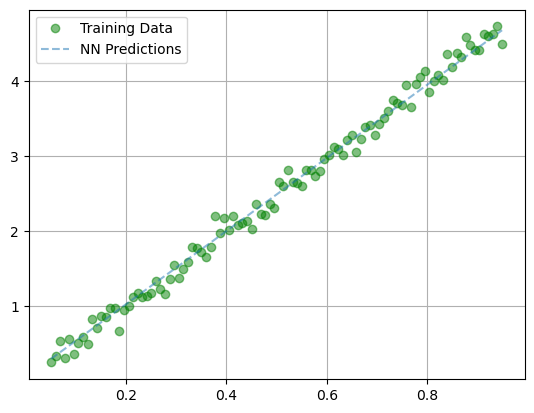

In [604]:

from matplotlib import pyplot as plt, rcParams
predicted = our_model(x_data_tensor)
plt.plot(x_data_tensor, y_data_tensor, 'go', label='Training Data', alpha=0.5)
plt.plot(x_data_tensor, Variable(predicted), '--', label='NN Predictions', alpha=0.5)
plt.legend(loc='best')
plt.grid()
plt.show()

## Now test on some sample $x$ values

What are the predicted $y$ values for the following?
- $x=-0.2$
- $x=0.8$
- $x=1.5$

In [605]:
# TO-DO: write prediction code here, using the model name

x_test = torch.tensor([[-0.2], [0.8], [1.5]])

for x in x_test:
    predict = our_model(x)
    print('prediction for {} = {}'.format(x,predict[0]))

prediction for tensor([-0.2000]) = -0.920280933380127
prediction for tensor([0.8000]) = 3.9532508850097656
prediction for tensor([1.5000]) = 7.364723205566406


# Exercise 3: Perceptron (40 points)

In this exercise we will use a multi-layer perceptron to learn a non-linear function $y=f(x)$.

You are given the $x$ and $y$ data, and the task is to produce a machine learning model that can predict $y$ for any given $x$.

As for Exercise 2, fill in the code blocks below to model the regression and predict the output for some test $x$ values.
(Look for the comments marked "TO-DO.")


In [606]:
import torch
from torch.autograd import Variable
x_data_tensor = torch.tensor([
    [0.0500], [0.0591], [0.0682], [0.0773], [0.0864],
    [0.0955], [0.1045], [0.1136], [0.1227], [0.1318],
    [0.1409], [0.1500], [0.1591], [0.1682], [0.1773],
    [0.1864], [0.1955], [0.2045], [0.2136], [0.2227],
    [0.2318], [0.2409], [0.2500], [0.2591], [0.2682],
    [0.2773], [0.2864], [0.2955], [0.3045], [0.3136],
    [0.3227], [0.3318], [0.3409], [0.3500], [0.3591],
    [0.3682], [0.3773], [0.3864], [0.3955], [0.4045],
    [0.4136], [0.4227], [0.4318], [0.4409], [0.4500],
    [0.4591], [0.4682], [0.4773], [0.4864], [0.4955],
    [0.5045], [0.5136], [0.5227], [0.5318], [0.5409],
    [0.5500], [0.5591], [0.5682], [0.5773], [0.5864],
    [0.5955], [0.6045], [0.6136], [0.6227], [0.6318],
    [0.6409], [0.6500], [0.6591], [0.6682], [0.6773],
    [0.6864], [0.6955], [0.7045], [0.7136], [0.7227],
    [0.7318], [0.7409], [0.7500], [0.7591], [0.7682],
    [0.7773], [0.7864], [0.7955], [0.8045], [0.8136],
    [0.8227], [0.8318], [0.8409], [0.8500], [0.8591],
    [0.8682], [0.8773], [0.8864], [0.8955], [0.9045],
    [0.9136], [0.9227], [0.9318], [0.9409], [0.9500]
])
y_data_tensor = torch.tensor([
    [ 1.7583], [ 1.7594], [ 1.8341], [ 1.6776], [ 1.6192],
    [ 1.6319], [ 1.2830], [ 1.4240], [ 1.2310], [ 1.1797],
    [ 1.1209], [ 1.0473], [ 0.9846], [ 0.8850], [ 0.5541],
    [ 0.6185], [ 0.3247], [ 0.2793], [ 0.2393], [ 0.1914],
    [-0.1365], [-0.3595], [-0.4752], [-0.5761], [-0.7215],
    [-0.6921], [-0.9243], [-0.8667], [-0.8986], [-1.0227],
    [-1.3271], [-1.2883], [-1.4789], [-1.4397], [-1.5957],
    [-1.6669], [-1.6963], [-1.5355], [-1.8969], [-1.8468],
    [-1.9558], [-2.1036], [-2.0511], [-2.0254], [-2.0736],
    [-2.1414], [-2.1034], [-1.8813], [-1.9003], [-1.8852],
    [-1.7806], [-1.8672], [-1.6624], [-1.7309], [-1.6294],
    [-1.4354], [-1.3698], [-1.3055], [-1.2557], [-1.0780],
    [-1.0991], [-0.9720], [-0.6129], [-0.6491], [-0.5295],
    [-0.3640], [-0.2636], [-0.0167], [ 0.0487], [ 0.0429],
    [ 0.1645], [ 0.2342], [ 0.2722], [ 0.6613], [ 0.6190],
    [ 0.8127], [ 1.0884], [ 1.1002], [ 1.0179], [ 1.3273],
    [ 1.2551], [ 1.3914], [ 1.6677], [ 1.5505], [ 1.6793],
    [ 1.6582], [ 1.7866], [ 1.9044], [ 1.8406], [ 1.9540],
    [ 2.0823], [ 2.0165], [ 1.8276], [ 1.9111], [ 2.0306],
    [ 2.2018], [ 1.9585], [ 1.9884], [ 1.8752], [ 1.8503]
])

Check the model being constructed.
What do you think is the best architecture to learn this dataset?
(You can change your mind later.)

In [607]:
#Because there are positive and negative y-values, sigmoid does not work well for this dataset
from torch import nn, optim
complex_model = nn.Sequential(
    nn.Linear(1, 4),
    nn.Tanh(),
    #nn.Sigmoid(),
    nn.Linear(4, 4),
    nn.Tanh(),
    nn.Linear(4, 1)
)

#This learning rate seemed to be the only one that didn't send the loss to inf -> nan 
criterion = nn.MSELoss()
optimizer = optim.SGD(complex_model.parameters(), lr=0.4)

In [608]:
#Because the learning rate is low, more epochs are needed to get the loss down. Also, more epochs seemed to be the ticket to a non-linear 
#prediction. I set it to roughly 1000 then went through 
for epoch in range(710):
    # Forward pass: Compute predicted y by passing x to the model
    pred_y = complex_model(x_data_tensor)
    loss = criterion(pred_y, y_data_tensor)

    # Zero gradients, perform a backward pass,
    # and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 0, loss 2.161327838897705
epoch 1, loss 2.0344741344451904
epoch 2, loss 2.012735366821289
epoch 3, loss 2.0032267570495605
epoch 4, loss 1.9979443550109863
epoch 5, loss 1.9933886528015137
epoch 6, loss 1.988929271697998
epoch 7, loss 1.9843257665634155
epoch 8, loss 1.9794487953186035
epoch 9, loss 1.9741873741149902
epoch 10, loss 1.9684388637542725
epoch 11, loss 1.962100863456726
epoch 12, loss 1.9550743103027344
epoch 13, loss 1.9472613334655762
epoch 14, loss 1.9385708570480347
epoch 15, loss 1.9289158582687378
epoch 16, loss 1.9182194471359253
epoch 17, loss 1.9064080715179443
epoch 18, loss 1.8934125900268555
epoch 19, loss 1.8791556358337402
epoch 20, loss 1.8635450601577759
epoch 21, loss 1.8464549779891968
epoch 22, loss 1.8277255296707153
epoch 23, loss 1.8071311712265015
epoch 24, loss 1.7844690084457397
epoch 25, loss 1.7596925497055054
epoch 26, loss 1.736070990562439
epoch 27, loss 1.7532397508621216
epoch 28, loss 2.2316384315490723
epoch 29, loss 4.064189910888

## Plot the output from your regression model over the same domain as the training data.

Does it make sense? If not, update the training procedure parameters until you are satisfied with the regression model.

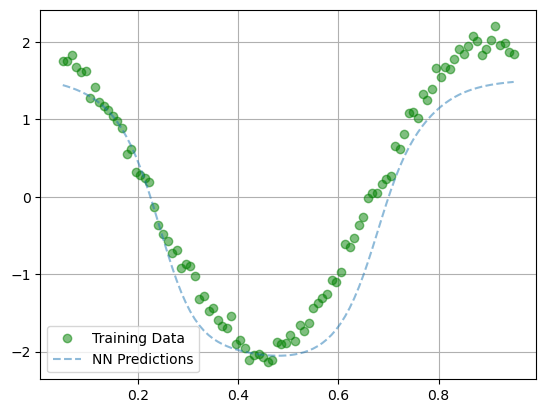

In [609]:
from matplotlib import pyplot as plt, rcParams
predicted = complex_model(x_data_tensor)
plt.plot(x_data_tensor, y_data_tensor, 'go', label='Training Data', alpha=0.5)
plt.plot(x_data_tensor, Variable(predicted), '--', label='NN Predictions', alpha=0.5)
plt.legend(loc='best')
plt.grid()
plt.show()

## Now test on some sample $x$ values

What are the predicted $y$ values for the following?
- $x=-0.2$
- $x=0.4$
- $x=0.8$

In [610]:

x_test = torch.tensor([[-0.2], [0.8], [1.5]])

for x in x_test:
    predict = complex_model(x)
    print('prediction for {} = {}'.format(x,predict[0]))

prediction for tensor([-0.2000]) = 1.597137451171875
prediction for tensor([0.8000]) = 1.140517234802246
prediction for tensor([1.5000]) = 1.5222320556640625
